# RAG

This notebook demonstrates a Retrieval-Augmented Generation application, which enhances language models by retrieving relevant information from documents.

It utilizes the following component:

- **PyPDFLoader**: Loads and extracts text from PDF files.
- **RecursiveCharacterTextSplitter**: Splits text into manageable chunks for processing.
- **SentenceTransformer("all-MiniLM-L6-v2")**: Generates dense vector embeddings for sentences to enable semantic search.
- **FAISS**: Performs efficient similarity search and indexing on the embeddings.
- **CrossEncoder("cross-encoder/ms-marco-MiniLM-L-6-v2")**: Re-ranks retrieved results for improved relevance.


In [ ]:
!pip install -U sentence-transformers faiss-cpu
!pip install -U langchain langchain-text-splitters
!pip install -U langchain-community pypdf

In [7]:
# Document ingestion pipeline
from langchain_community.document_loaders import PyPDFLoader

pdf_path = "./../data/Environmental Planning and Assessment Act 1979 No 203.pdf"
loader = PyPDFLoader(pdf_path)
documents = loader.load()
print("Number of pages loaded:", len(documents))

Number of pages loaded: 343


In [8]:
# chunking the documents
from langchain_text_splitters import RecursiveCharacterTextSplitter

text_splitter = RecursiveCharacterTextSplitter(chunk_size=500, chunk_overlap=100)
chunks = text_splitter.split_documents(documents)
print("Number of chunks created:", len(chunks))

Number of chunks created: 2102


In [9]:
# embedding the chunks

import faiss
import numpy as np
from sentence_transformers import SentenceTransformer

model = SentenceTransformer("all-MiniLM-L6-v2")
embeddings = model.encode([chunk.page_content for chunk in chunks])
dimension = embeddings.shape[1]
print("Dimension of the embeddings:", dimension)

index = faiss.IndexFlatL2(dimension)
index.add(np.array(embeddings))
print("Number of vectors in the index:", index.ntotal)

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Dimension of the embeddings: 384
Number of vectors in the index: 2102


In [21]:
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA


def show_pca_plot(embeddings, query_embedding=None, chunk_count=10):
    pca = PCA(n_components=2)
    reduced_embeddings = (
        pca.fit_transform(embeddings)
        if query_embedding is None
        else pca.fit_transform(np.vstack([embeddings, query_embedding]))
    )

    plt.scatter(
        reduced_embeddings[:chunk_count, 0],
        reduced_embeddings[:chunk_count, 1],
        color="blue",
        label="Document Chunks",
    )
    if query_embedding is not None:
        plt.scatter(
            reduced_embeddings[-1, 0],
            reduced_embeddings[-1, 1],
            color="red",
            label="Query Embedding",
            s=100,
        )

    # add annotation
    for i in range(chunk_count):
        plt.annotate(
            f"Ck {i}",
            (reduced_embeddings[i, 0], reduced_embeddings[i, 1]),
            ha="center",
            va="bottom",
        )
    plt.title("PCA")
    plt.xlabel("Principal Component 1")
    plt.ylabel("Principal Component 2")
    plt.show()

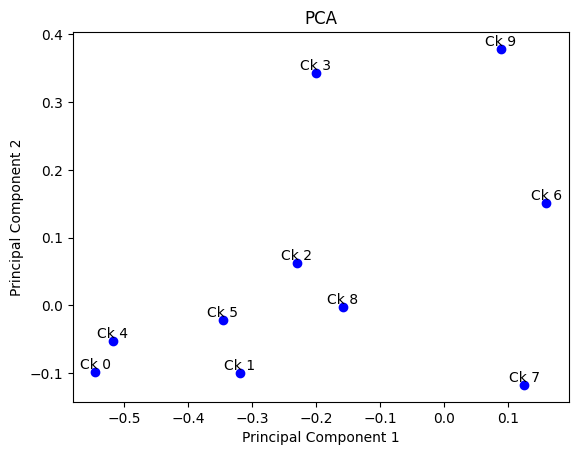

In [22]:
show_pca_plot(embeddings)

In [15]:
# retrieving similar chunks
query = "What does the 'prohibited development' mean?"
query_embedding = model.encode([query])
k = 5
_distances, indices = index.search(np.array(query_embedding), k)
retrieved_chunks = [chunks[i] for i in indices[0]]  # 0 because we have only one query

print("Top similar chunks:")
for chunk in retrieved_chunks:
    print(f"Chunk Index: {chunks.index(chunk)}")
    print(f'Page Number: {chunk.metadata["page"]}')
    print(f"{chunk.page_content[:200]}...")
    print("-" * 50)

Top similar chunks:
Chunk Index: 526
Page Number: 80
development, or a class of development, that can be addressed by specified
predetermined development standards is complying development.
(6)–(9) (Repealed)
Note.
Division 4.7 makes provision with resp...
--------------------------------------------------
Chunk Index: 204
Page Number: 26
licence under the Home Building Act 1989.
prohibited development means—
(a) development the carrying out of which is prohibited on land by the provisions of
an environmental planning instrument that a...
--------------------------------------------------
Chunk Index: 831
Page Number: 130
(a) the use of a building, work or land for a lawful purpose immediately before the coming
into force of an environmental planning instrument which would, but for this Division,
have the effect of pro...
--------------------------------------------------
Chunk Index: 808
Page Number: 126
(b) A requirement that a development application to carry out development, being


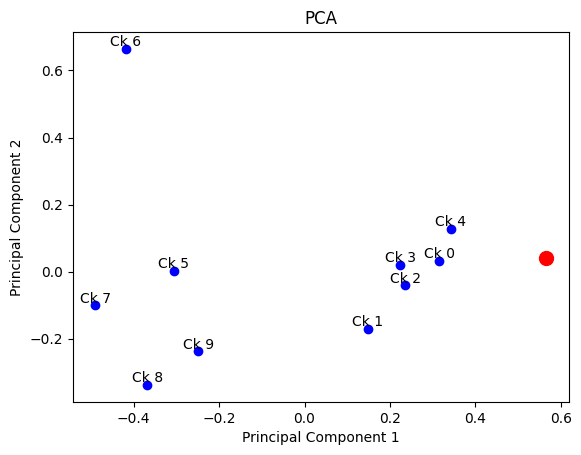

In [23]:
retrieved_embeddings = [embeddings[i] for i in indices[0]]
other_random_embeddings = [
    embeddings[i]
    for i in np.random.randint(0, len(embeddings), size=5)
    if i not in indices[0]
]
combined_embeddings = np.vstack([retrieved_embeddings, other_random_embeddings])
show_pca_plot(combined_embeddings, query_embedding=query_embedding)

In [16]:
# re-ranking the retrieved chunks
from sentence_transformers import CrossEncoder

reranker = CrossEncoder("cross-encoder/ms-marco-MiniLM-L-6-v2")
pairs = [(query, chunk.page_content) for chunk in retrieved_chunks]
rerank_scores = reranker.predict(pairs)
reranked_chunks = sorted(
    zip(retrieved_chunks, rerank_scores), key=lambda x: x[1], reverse=True
)

print("Re-ranked chunks:")
for chunk, score in reranked_chunks:
    print(f"Re-rank Score: {score:.4f}")
    print(f"Chunk Index: {chunks.index(chunk)}")
    print(f'Page Number: {chunk.metadata["page"]}')
    print(f"{chunk.page_content[:200]}...")
    print("-" * 50)

Loading weights:   0%|          | 0/105 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: cross-encoder/ms-marco-MiniLM-L-6-v2
Key                          | Status     |  | 
-----------------------------+------------+--+-
bert.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Re-ranked chunks:
Re-rank Score: 9.1305
Chunk Index: 204
Page Number: 26
licence under the Home Building Act 1989.
prohibited development means—
(a) development the carrying out of which is prohibited on land by the provisions of
an environmental planning instrument that a...
--------------------------------------------------
Re-rank Score: 3.9881
Chunk Index: 526
Page Number: 80
development, or a class of development, that can be addressed by specified
predetermined development standards is complying development.
(6)–(9) (Repealed)
Note.
Division 4.7 makes provision with resp...
--------------------------------------------------
Re-rank Score: 3.5656
Chunk Index: 527
Page Number: 80
(a) specified development is prohibited on land to which the provision applies, or
(b) development cannot be carried out on land with or without development consent,
a person must not carry out the de...
--------------------------------------------------
Re-rank Score: 0.5077
Chunk Index: 831
Page Number: 

In [17]:
# combine the top re-ranked chunks into a single context
top_chunks = [chunk for chunk, score in reranked_chunks[:3]]  # top 3 chunks
context = "\n\n".join([chunk.page_content for chunk in top_chunks])
print(context[:1000])  # print the first 1000 characters of the context

licence under the Home Building Act 1989.
prohibited development means—
(a) development the carrying out of which is prohibited on land by the provisions of
an environmental planning instrument that apply to the land, or
(b) development that cannot be carried out on land with or without development
consent.
provision for fire safety means provision for any or all of the following—
Environmental Planning and Assessment Act 1979 No 203 [NSW]

development, or a class of development, that can be addressed by specified
predetermined development standards is complying development.
(6)–(9) (Repealed)
Note.
Division 4.7 makes provision with respect to State significant development.
4.3 Development that is prohibited (cf previous s 76B)
If an environmental planning instrument provides that—
(a) specified development is prohibited on land to which the provision applies, or

(a) specified development is prohibited on land to which the provision applies, or
(b) development cannot be carried out on

In [18]:
# Calling the LLM with the retrieved context
import openai

prompt = f"""
Answer the question based on the following context:

===START OF CONTEXT===
{context}
===END OF CONTEXT===

Question: {query}

Provide a concise answer based on the context.
If the answer is not found in the context, say "Answer not found in the provided context."
"""

client = openai.OpenAI()
response = client.chat.completions.create(
    model="gpt-4o-mini", messages=[{"role": "user", "content": prompt}]
)
answer = response.choices[0].message.content.strip()
print("Answer:", answer)

Answer: 'Prohibited development' means development that is either (a) prohibited on land by the provisions of an environmental planning instrument that apply to the land, or (b) development that cannot be carried out on land, with or without development consent.
